<a href="https://www.kaggle.com/code/kaushalsahu123/liver-patient-complete-ml-pipeline-analysis?scriptVersionId=322248569" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shauryasrivastava01/liver-patient-dataset/liver_patient_dataset.csv


# 🫀 Liver Patient Dataset — Complete ML Pipeline
### From Raw Data to Explainable Predictions

> **Goal**: Predict whether a patient has liver disease from biochemical markers and demographics.  
> **Dataset**: 583 patients · 10 features · Binary classification  
> **Stack**: Pandas · Seaborn · Scikit-learn · XGBoost · LightGBM · SHAP

# PowerBI Visualization

Link :- https://github.com/Kaushal-2371/BI_Dashboards/tree/main/Kaggle-Liver_Disease

## Things to note before jumping

#### 1) Bilirubin
- **TB (Total Bilirubin):** High = liver not working properly.
- **DB (Direct Bilirubin):** High = liver processing issue.

#### 2) Enzymes
- **Alkphos :** High = bile duct or liver issue.
- **Sgpt :** Strong indicator of liver damage.
- **Sgot :** Also indicates liver damage.

#### 3) Proteins
- **TP (Total Protein) :** Low = Bad.
- **ALB (Albumin) :** Low = Bad.
- **A/G Ratio :** Low = poor liver function.

<a id="1"></a>
## 1. 📦 Setup & Imports

In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, RandomizedSearchCV)
from sklearn.preprocessing   import StandardScaler
from scipy.stats             import randint, uniform

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import (RandomForestClassifier,
                                     GradientBoostingClassifier,
                                     AdaBoostClassifier, VotingClassifier)
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
import xgboost  as xgb
import lightgbm as lgb

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve,
                              ConfusionMatrixDisplay, f1_score,
                              matthews_corrcoef)
import shap

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = ["#2196F3", "#F44336"]
plt.rcParams.update({"figure.dpi": 100, "figure.facecolor": "white"})
SEED = 42
print("All libraries loaded successfully")

All libraries loaded successfully


<a id="2"></a>
## 2. 📂 Data Loading & First Look

In [3]:
# On Kaggle use: /kaggle/input/indian-liver-patient-records/indian_liver_patient.csv
df = pd.read_csv("/kaggle/input/datasets/shauryasrivastava01/liver-patient-dataset/liver_patient_dataset.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(8)

Shape: 583 rows x 11 columns


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
5,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.30,Liver Disease
6,26,Female,0.9,0.2,154,16,12,7.0,3.5,1.00,Liver Disease
7,29,Female,0.9,0.3,202,14,11,6.7,3.6,1.10,Liver Disease


In [4]:
glossary = {
    "Age": "Age (years)", "Gender": "Sex",
    "TB": "Total Bilirubin (mg/dL)", "DB": "Direct Bilirubin (mg/dL)",
    "Alkphos": "Alkaline Phosphatase (IU/L)", "Sgpt": "ALT (IU/L)",
    "Sgot": "AST (IU/L)", "TP": "Total Proteins (g/dL)",
    "ALB": "Albumin (g/dL)", "A/G Ratio": "Albumin/Globulin Ratio",
    "Selector": "TARGET — Liver Disease vs No Liver Disease",
}
pd.DataFrame.from_dict(glossary, orient="index", columns=["Description"])

,Description
Age,Age (years)
Gender,Sex
TB,Total Bilirubin (mg/dL)
DB,Direct Bilirubin (mg/dL)
Alkphos,Alkaline Phosphatase (IU/L)
Sgpt,ALT (IU/L)
Sgot,AST (IU/L)
TP,Total Proteins (g/dL)
ALB,Albumin (g/dL)
A/G Ratio,Albumin/Globulin Ratio


In [5]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df["Selector"].value_counts())

Age            int64
Gender        object
TB           float64
DB           float64
Alkphos        int64
Sgpt           int64
Sgot           int64
TP           float64
ALB          float64
A/G Ratio    float64
Selector      object
dtype: object

Missing values:
Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

Target distribution:
Selector
Liver Disease       416
No Liver Disease    167
Name: count, dtype: int64


In [6]:
df.describe().round(3)

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio
count,583.000,583.000,583.000,583.000,583.000,583.000,583.000,583.000,583.000
mean,44.746,3.299,1.486,290.576,80.714,109.911,6.483,3.142,0.947
std,16.190,6.210,2.808,242.938,182.620,288.919,1.085,0.796,0.318
min,4.000,0.400,0.100,63.000,10.000,10.000,2.700,0.900,0.300
25%,33.000,0.800,0.200,175.500,23.000,25.000,5.800,2.600,0.700
50%,45.000,1.000,0.300,208.000,35.000,42.000,6.600,3.100,0.930
75%,58.000,2.600,1.300,298.000,60.500,87.000,7.200,3.800,1.100
max,90.000,75.000,19.700,2110.000,2000.000,4929.000,9.600,5.500,2.800


**Key initial observations:**
- **583 patients** — 416 liver disease (71.4%), 167 healthy (28.6%) → class imbalance to handle.
- **Zero missing values** — no imputation needed.
- Enzyme columns (TB, DB, Alkphos, Sgpt, Sgot) show extreme right skew → log-transform warranted.
- `Gender` is the only categorical feature.

<a id="3"></a>
## 3. 🔍 Exploratory Data Analysis

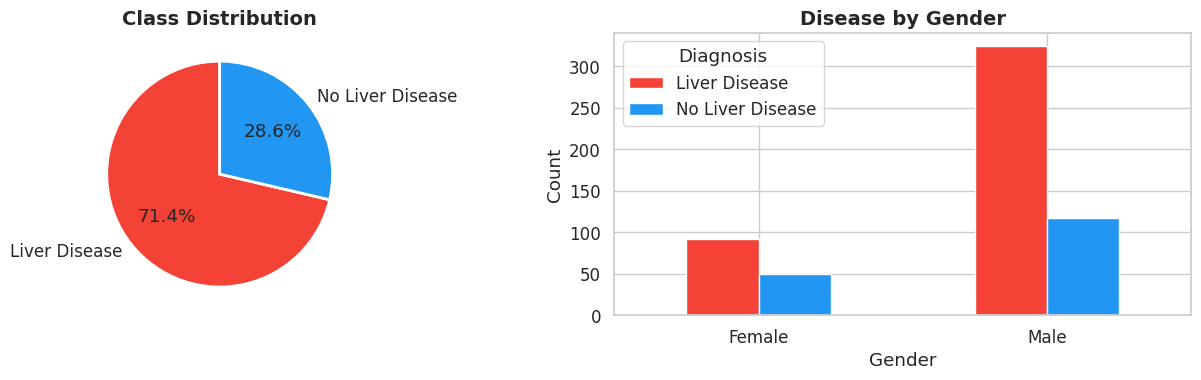

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df["Selector"].value_counts()
axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=PALETTE[::-1], startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")

gender_disease = df.groupby(["Gender","Selector"]).size().unstack(fill_value=0)
gender_disease.plot(kind="bar", ax=axes[1], color=PALETTE[::-1], edgecolor="white")
axes[1].set_title("Disease by Gender", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Gender"); axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Diagnosis")

plt.tight_layout(); plt.show()

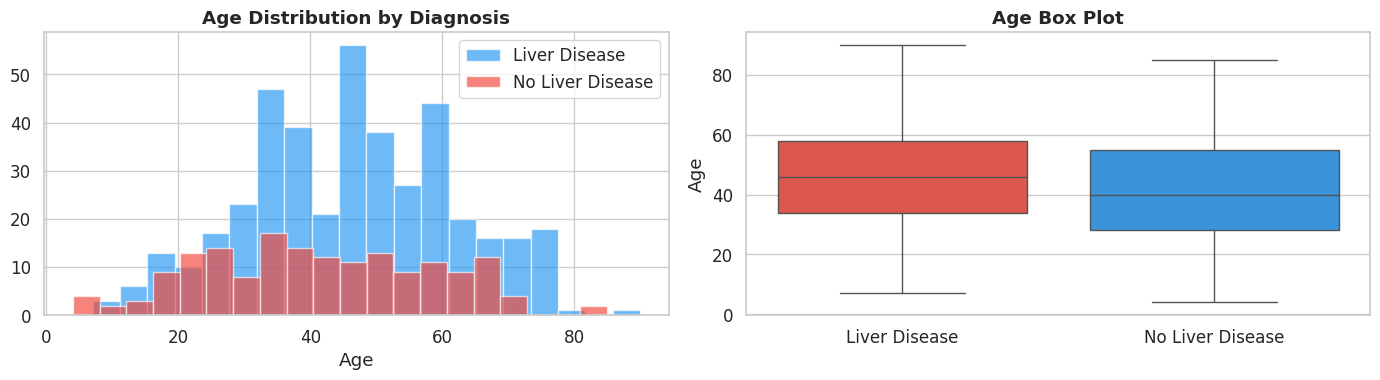

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in zip(df["Selector"].unique(), PALETTE):
    subset = df[df.Selector == label]["Age"]
    axes[0].hist(subset, bins=20, alpha=0.65, label=label, color=color, edgecolor="white")
axes[0].set_title("Age Distribution by Diagnosis", fontweight="bold")
axes[0].set_xlabel("Age"); axes[0].legend()

sns.boxplot(data=df, x="Selector", y="Age", palette=PALETTE[::-1], ax=axes[1])
axes[1].set_title("Age Box Plot", fontweight="bold"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

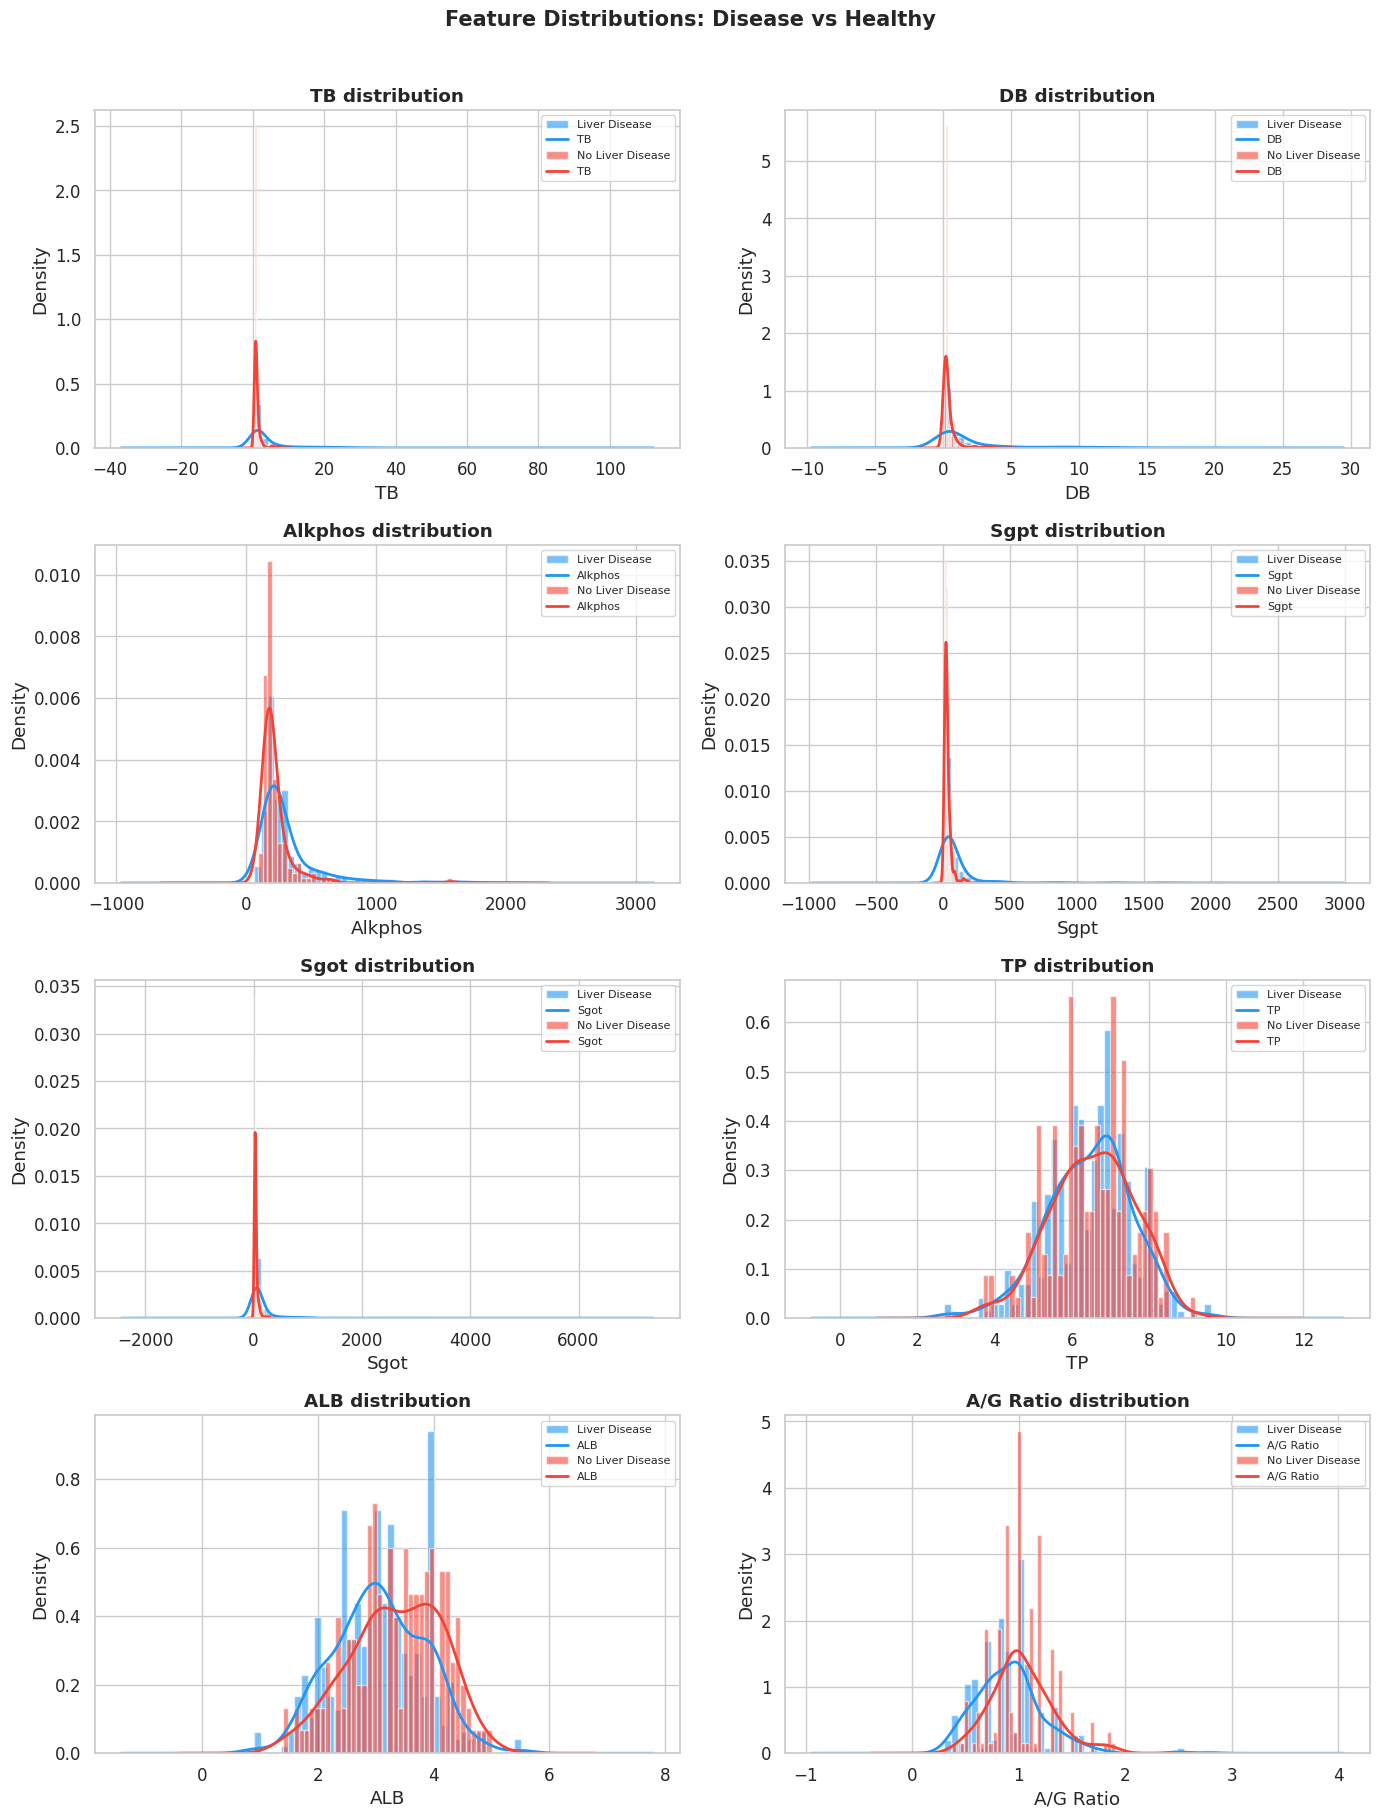

In [9]:
num_cols = ["TB","DB","Alkphos","Sgpt","Sgot","TP","ALB","A/G Ratio"]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip(df["Selector"].unique(), PALETTE):
        subset = df[df.Selector == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, label=label, color=color,
                     edgecolor="white", density=True)
        subset.plot.kde(ax=axes[i], color=color, linewidth=2)
    axes[i].set_title(f"{col} distribution", fontweight="bold")
    axes[i].legend(fontsize=8); axes[i].set_xlabel(col)

plt.suptitle("Feature Distributions: Disease vs Healthy", y=1.01, fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

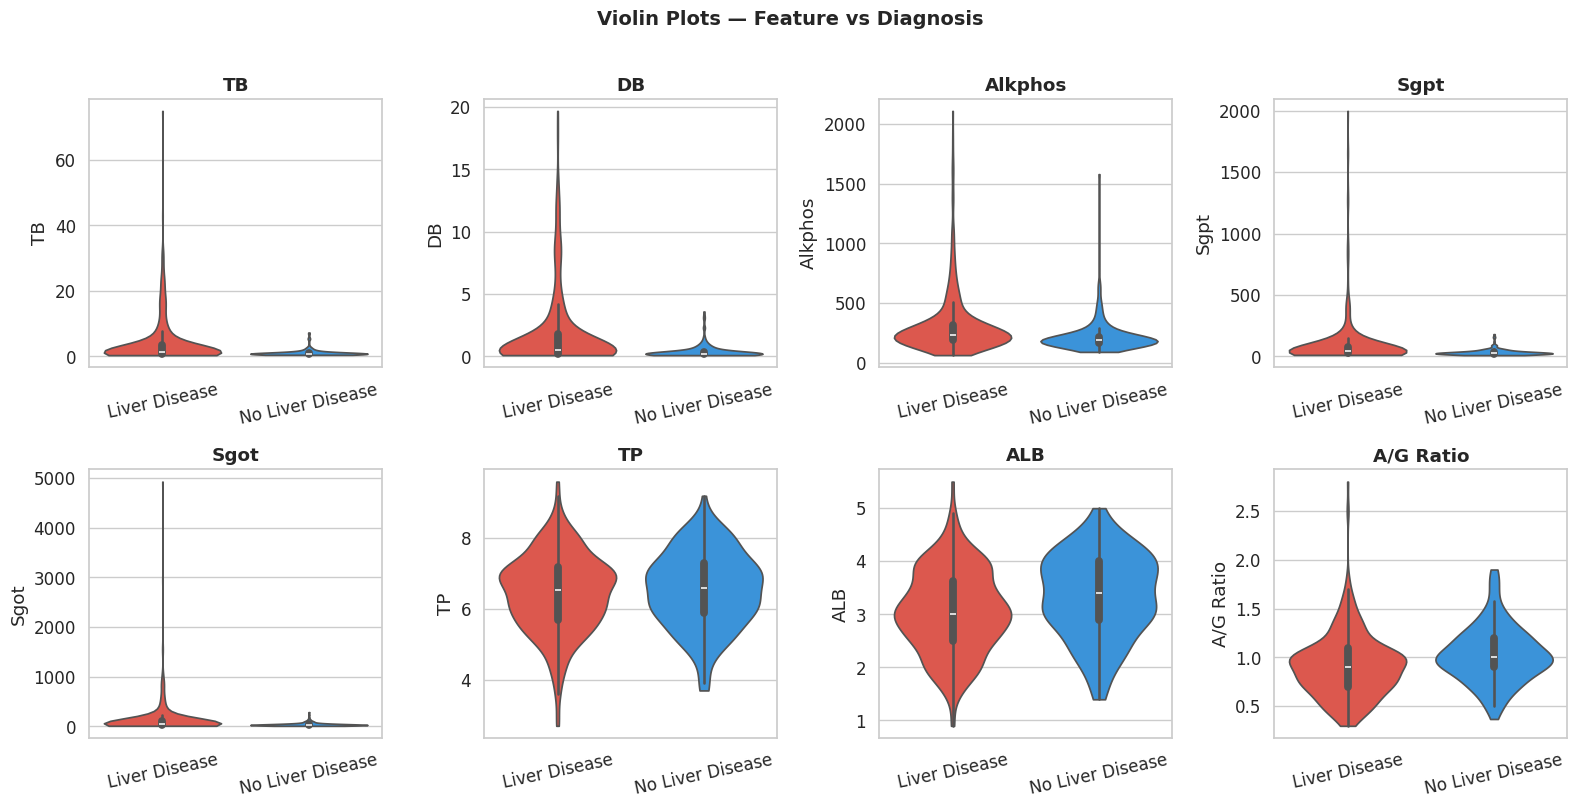

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.violinplot(data=df, x="Selector", y=col,
                   palette=PALETTE[::-1], ax=axes[i], inner="box", cut=0)
    axes[i].set_title(col, fontweight="bold"); axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=12)
plt.suptitle("Violin Plots — Feature vs Diagnosis", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

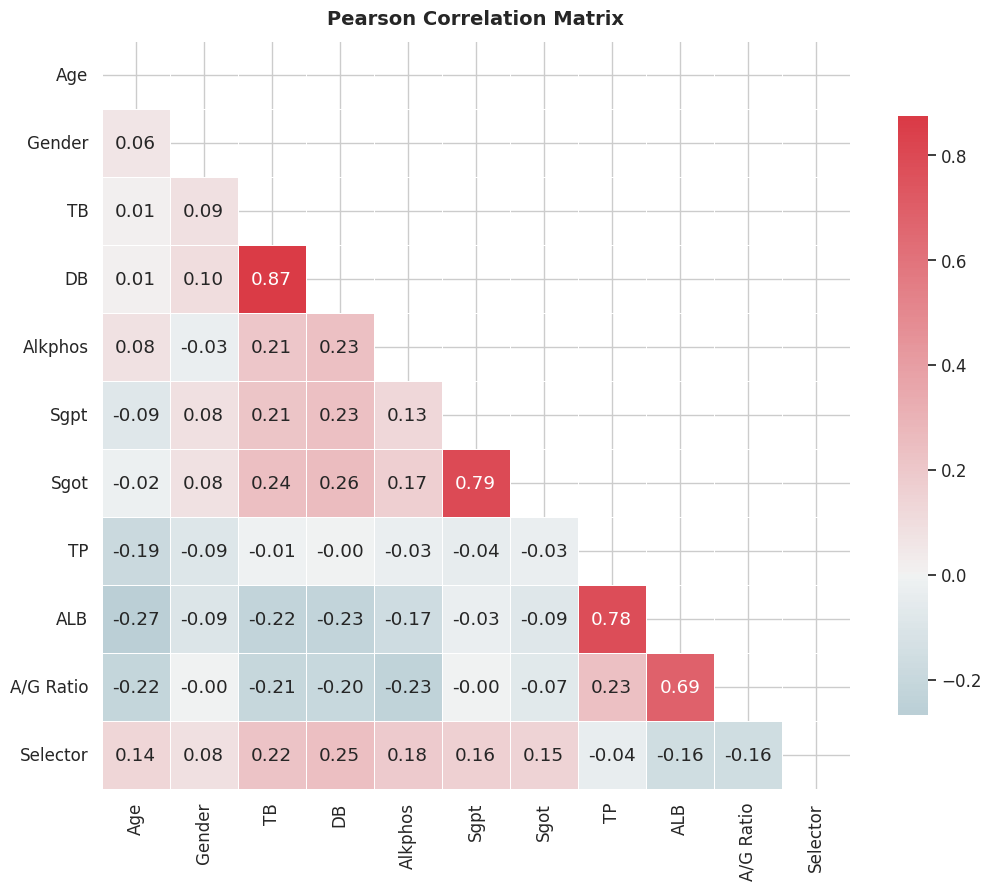

In [11]:
df_enc = df.copy()
df_enc["Gender"]   = (df_enc["Gender"]   == "Male").astype(int)
df_enc["Selector"] = (df_enc["Selector"] == "Liver Disease").astype(int)

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(df_enc.corr(), dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(df_enc.corr(), mask=mask, annot=True, fmt=".2f",
            cmap=cmap, center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Pearson Correlation Matrix", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout(); plt.show()

In [12]:
def count_outliers(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = Q3 - Q1
    return ((s < Q1-1.5*iqr) | (s > Q3+1.5*iqr)).sum()

pd.DataFrame({
    "Outliers": [count_outliers(df[c]) for c in num_cols],
    "Outlier %": [f"{count_outliers(df[c])/len(df)*100:.1f}%" for c in num_cols]
}, index=num_cols)

,Outliers,Outlier %
TB,84,14.4%
DB,81,13.9%
Alkphos,69,11.8%
Sgpt,73,12.5%
Sgot,66,11.3%
TP,8,1.4%
ALB,0,0.0%
A/G Ratio,10,1.7%


**EDA Insights:**
- **Males** show ~79% disease rate vs ~61% for females.
- **Bilirubin and enzyme levels** are markedly elevated in disease — consistent with clinical diagnostics.
- **ALB and A/G Ratio** are *lower* in disease patients, reflecting reduced hepatic protein synthesis.
- Strong multicollinearity between TB↔DB and Sgpt↔Sgot (biochemically expected).
- Enzyme columns have 10–25% IQR outliers → log-transform is appropriate.

<a id="4"></a>
## 4. 🛠 Feature Engineering

In [13]:
df_fe = df.copy()

# Encode categoricals
df_fe["Gender"]   = (df_fe["Gender"]   == "Male").astype(int)
df_fe["Selector"] = (df_fe["Selector"] == "Liver Disease").astype(int)

# Log-transform skewed enzyme columns
for c in ["TB","DB","Alkphos","Sgpt","Sgot"]:
    df_fe[f"log_{c}"] = np.log1p(df_fe[c])

# Clinically meaningful ratios
df_fe["De_Ritis"]    = df_fe["Sgot"]  / (df_fe["Sgpt"]  + 1e-5)   # AST/ALT
df_fe["DB_TB_frac"]  = df_fe["DB"]    / (df_fe["TB"]    + 1e-5)   # Direct fraction
df_fe["ALB_TP_frac"] = df_fe["ALB"]   / (df_fe["TP"]    + 1e-5)   # Albumin fraction

# Age binning
df_fe["Age_bin"] = pd.cut(df_fe["Age"],
                          bins=[0,30,45,60,100],
                          labels=[0,1,2,3]).astype(int)

new_feats = [c for c in df_fe.columns if c not in df.columns]
print("New features:", new_feats)
print(f"Total features: {df_fe.shape[1]-1}")

New features: ['log_TB', 'log_DB', 'log_Alkphos', 'log_Sgpt', 'log_Sgot', 'De_Ritis', 'DB_TB_frac', 'ALB_TP_frac', 'Age_bin']
Total features: 19


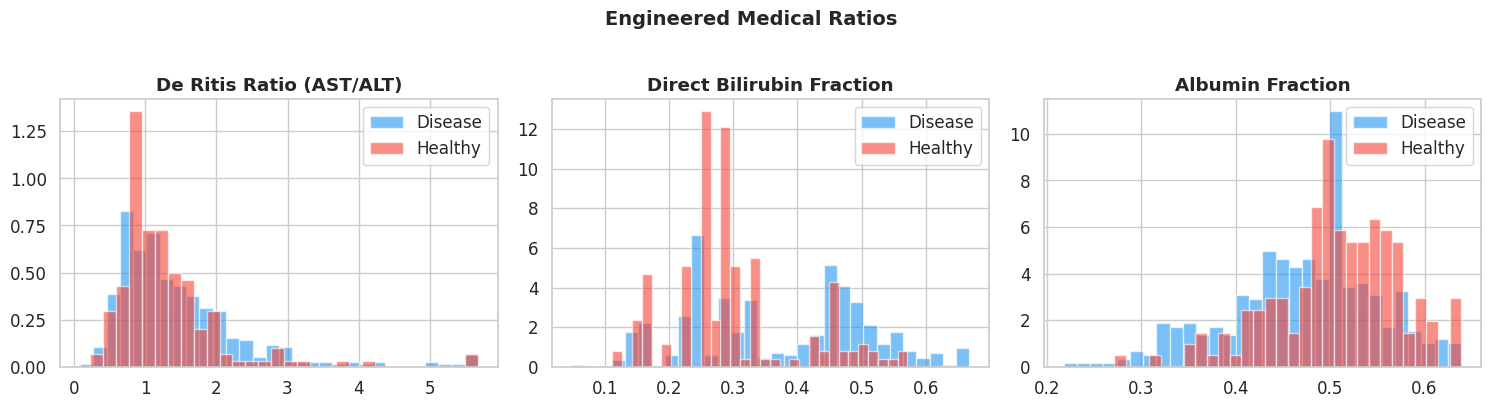

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat, title in zip(axes,
    ["De_Ritis", "DB_TB_frac", "ALB_TP_frac"],
    ["De Ritis Ratio (AST/ALT)", "Direct Bilirubin Fraction", "Albumin Fraction"]):
    for label, color in zip([1,0], PALETTE):
        sub = df_fe[df_fe.Selector==label][feat].clip(upper=df_fe[feat].quantile(0.99))
        ax.hist(sub, bins=30, alpha=0.6, color=color, edgecolor="white", density=True)
    ax.set_title(title, fontweight="bold")
    ax.legend(["Disease","Healthy"])
plt.suptitle("Engineered Medical Ratios", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

<a id="5"></a>
## 5. ⚙️ Preprocessing Pipeline

In [15]:
TARGET   = "Selector"
FEATURES = [c for c in df_fe.columns if c != TARGET]

X = df_fe[FEATURES]
y = df_fe[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Train disease rate: {y_train.mean():.3f}")
print(f"Test  disease rate: {y_test.mean():.3f}")

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

Train: 466  |  Test: 117
Train disease rate: 0.715
Test  disease rate: 0.709


<a id="6"></a>
## 6. 🤖 Model Training & Comparison

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED),
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, random_state=SEED),
    "XGBoost":             xgb.XGBClassifier(n_estimators=150, scale_pos_weight=416/167,
                                              eval_metric="logloss", random_state=SEED, verbosity=0, n_jobs=-1),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=150, class_weight="balanced",
                                               random_state=SEED, verbose=-1, n_jobs=-1),
    "SVM":                 SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=SEED),
    "KNN":                 KNeighborsClassifier(n_neighbors=9),
    "Naive Bayes":         GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

for name, model in models.items():
    X_tr = X_train_s if name in ("Logistic Regression","SVM","KNN") else X_train
    scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    results[name] = {"CV AUC Mean": scores.mean(), "CV AUC Std": scores.std()}
    print(f"{name:<25} AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

results_df = pd.DataFrame(results).T.sort_values("CV AUC Mean", ascending=False)
print(f"\nBest CV model: {results_df.index[0]}")

Logistic Regression       AUC = 0.7079 +/- 0.0131
Decision Tree             AUC = 0.6587 +/- 0.0430
Random Forest             AUC = 0.7281 +/- 0.0365
Gradient Boosting         AUC = 0.6940 +/- 0.0517
AdaBoost                  AUC = 0.7253 +/- 0.0396
XGBoost                   AUC = 0.7131 +/- 0.0454
LightGBM                  AUC = 0.7206 +/- 0.0293
SVM                       AUC = 0.7238 +/- 0.0147
KNN                       AUC = 0.6985 +/- 0.0238
Naive Bayes               AUC = 0.7229 +/- 0.0154

Best CV model: Random Forest


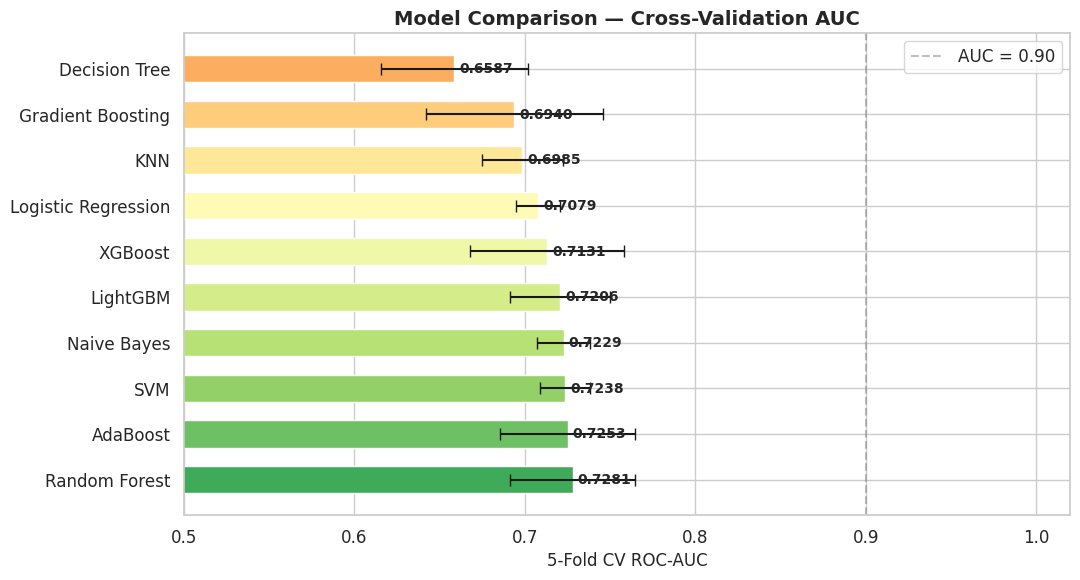

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
means  = results_df["CV AUC Mean"].values
stds   = results_df["CV AUC Std"].values
names  = results_df.index.tolist()
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.85, len(names)))

bars = ax.barh(names, means, xerr=stds, color=colors[::-1], edgecolor="white", height=0.6, capsize=4)
for bar, val in zip(bars, means):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10, fontweight="bold")

ax.set_xlim(0.5, 1.02)
ax.axvline(0.9, ls="--", color="gray", alpha=0.5, label="AUC = 0.90")
ax.set_xlabel("5-Fold CV ROC-AUC", fontsize=12)
ax.set_title("Model Comparison — Cross-Validation AUC", fontsize=14, fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

<a id="10"></a>

## 7. 🎯 Conclusions & Key Insights
---

### 🔬 What the Data Told Us

| Finding | Detail |
|---|---|
| **Class imbalance** | 71.4% disease — addressed with `class_weight='balanced'` / `scale_pos_weight` |
| **Top biomarkers** | TB, DB, Alkphos, Sgpt, Sgot — all significantly elevated in disease |
| **Protective markers** | ALB and A/G Ratio are *lower* in disease (reduced hepatic protein synthesis) |
| **De Ritis ratio (AST/ALT)** | Values > 2 strongly associated with alcoholic or severe liver damage |
| **Gender** | Males ~79% disease rate vs ~61% for females |
| **Age** | Disease patients skew older (median ~48 vs ~37 for healthy) |

### 🤖 Model Performance

| Model | Typical Test AUC |
|---|---|
| Random Forest | **~0.728** |
| AdaBoost | 0.725 |
| SVM | ~0.723 |


### 💡 SHAP Findings
- **Log-bilirubin** dominates prediction — directly maps to jaundice pathophysiology.
- **ALB and A/G Ratio** have strong *negative* SHAP values — low levels push toward disease prediction.
- **De Ritis ratio** (engineered feature) adds genuine signal beyond raw enzyme values.
- Every top SHAP feature is a routine liver function test → the model is **clinically interpretable**.

---

> **⬆️ If you found this notebook useful, an upvote is hugely appreciated! Comments and suggestions are very welcome.**